In [13]:
import numpy as np
import re
from ase.symbols import string2symbols
import itertools
import pandas as pd
import sys
import os
import json



class Species:
    def __init__(self, name, phase, energy, activity=None, ligand_concentration = None):
        self.name = name
        self.formula = self.name.split('(aq)')[0]
        self.phase = phase
        self.energy = energy
        self.mass_balance = None  # Will be computed later
        self.ligand = None
        self.activity = activity
        self.alloy = False
        if self.phase == 'complex':
            self.composition, self.ligand = self.parse_complex_composition()
#             self.activity = ligand_concentration[self.formula]
        else:
            self.composition = self.parse_composition()
        self.mass_balance = self.compute_mass_balance()
        
    
    def parse_composition(self):
        """Parses the chemical formula to determine element composition."""
        
        formula  = self.formula
        composition = {'charge': 0, 'H': 0, 'O': 0}
        match = re.search(r'\[(\d*)([+-])\]', formula)
        if match:
            charge = match.group(1)
            sign = match.group(2)
            composition['charge'] = int(sign + charge)

        element_only_form = formula.split('[')[0]
        symbol_list = string2symbols(element_only_form)
        n_metal = 0
        for symbol in symbol_list:
            if symbol not in composition:
                n_metal += 1
            if symbol in composition:
                composition[symbol] += 1
            else:
                composition[symbol] = 1
        if n_metal > 1:
            self.alloy = True
#             print(self.formula)
        return composition
    
    def parse_complex_composition(self):
        formula  = self.formula
        composition = {'H': 0,
                       'O': 0,
                       'charge': 0}
        ############## count n of electrons and protons ##############
        match = re.search(r'\[(\d*)([+-])\]', formula)
        if match:
            charge = match.group(1)
            sign = match.group(2)
            composition['charge'] = int(sign + charge)
        ############## count n of ligands ##############
        pattern = r'([A-Za-z]+)?\(?([A-Za-z0-9]+)\)?(\d*)'
        match = re.search(pattern, formula)
        if match:
            metal = match.group(1)      # Metal symbol (e.g., Ni)
            ligand = match.group(2)     # Ligand (e.g., NH3)
            ligand_count = match.group(3)  # Ligand count (e.g., 4, could be empty)
            # If the ligand count is empty, it means it's 1
            ligand_count = int(ligand_count) if ligand_count else 1
        composition[ligand] = ligand_count
        ############## count n of metal ##############
        element_only_form = formula.split('(')[0]
        symbol_list = string2symbols(element_only_form)
        for symbol in symbol_list:
            if symbol in composition:
                composition[symbol] += 1
            else:
                composition[symbol] = 1
        return composition, ligand

    def compute_mass_balance(self):
        """Computes mass balance properties for reactions."""
        
        composition = self.composition
        mass_balance = {'n_H2O': 0, 'n_charge': 0, 'n_L': {}, 'n_H': 0}
        n_L = {}

        if self.phase == 'complex':
            n_L[self.ligand] = composition[self.ligand]  

        mass_balance['n_H2O'] = composition['O']
        mass_balance['n_H'] = composition['H'] - 2 * composition['O']
        mass_balance['n_charge'] = mass_balance['n_H'] - composition['charge']
        mass_balance.update({ 'n_L': n_L})
        
        return mass_balance


In [14]:
from pymatgen.analysis.reaction_calculator import Reaction
from pymatgen.core import Composition

class PourbaixData:
    def __init__(self, species_data, activity, ligand_concentration, reference_composition):
        self.mu_ligand = species_data.mu_ligand
        self.metal_reference = species_data.metal_reference
        self.stable_species_names = species_data.stable_species
        self.ligand_concentration = ligand_concentration
        self.reference_composition = reference_composition
        self.activity = activity
        self.all_species_list = []
        for species, energy in species_data.solid_eng.items():
            solid_species = Species(species, 'solid', energy)
            self.all_species_list.append(solid_species)

        for species, energy in species_data.ion_eng.items():
            self.all_species_list.append(Species(species, 'ion', energy, activity))
            
        self.stable_species_list = self.filter_stable_species()
        
        for species, energy in species_data.metal_complex.items():
            self.stable_species_list.append(Species(species, 'complex', energy, activity = activity, ligand_concentration = ligand_concentration))
            
            self.all_species_list.append(Species(species, 'complex', energy, activity = activity, ligand_concentration = ligand_concentration))

        self.reaction_coefficients = {}
        
        self.compute_reaction_coefficients()


    def filter_stable_species(self):
        """Filters species that are in the stable species or are alloy."""
        stable_species_list = []
        for species in self.all_species_list:              
            if species.name in self.stable_species_names or all(metal in species.composition for metal in self.metal_reference):
                stable_species_list.append(species)
        return stable_species_list

    def generate_species_combinations(self):
        """Generates valid species combinations."""
        all_combinations = [list(itertools.combinations(self.stable_species_list, r)) for r in range(1, len(self.metal_reference) + 1)]
        return list(itertools.chain.from_iterable(all_combinations))
    
    def contains_required_metals(self, combo):
        required_metals = set(self.metal_reference.keys())  
        metals_in_combo = set()
        for species in combo:
            for metal in required_metals:
                if metal in species.composition:
                    metals_in_combo.add(metal)
        return metals_in_combo >= required_metals  

    # The following methods are based on pymatgen.analysis.pourbaix_diagram
    def compute_reaction_coefficients(self):
        """Calculates reaction coefficients for each species combination."""
        species_combinations = self.generate_species_combinations()
        for combo in species_combinations:
            if self.contains_required_metals(combo):
                coefficients = self.compute_reaction_coefficients_for_combo(combo)
                if coefficients:
                    self.reaction_coefficients[combo] = coefficients

                
    def compute_reaction_coefficients_for_combo(self, combo_tuple, coeff_threshold=1e-4):
        """Calculates reaction coefficients using pymatgen's reaction calculator."""
        dummy_oh = [Composition("H"), Composition("O")]
        comp_dict = {metal: 1 / len(self.metal_reference) for metal in self.metal_reference}
        prod_comp = self.reference_composition #Composition(comp_dict)
        
        composition_list = []
        for species in combo_tuple:
            metal_composition_dict = {key: species.composition[key] for key in species.composition if key in self.metal_reference}
            composition_list.append(Composition(metal_composition_dict))
        try:
            rxn = Reaction(composition_list + dummy_oh, [prod_comp])
            
            react_coeffs = [-coeff for coeff in rxn.coeffs[:len(combo_tuple)]]
            all_coeffs = [*react_coeffs, rxn.get_coeff(prod_comp)]
            if all(coeff > coeff_threshold for coeff in all_coeffs):
                return react_coeffs
            return None
        except:
            return None


In [15]:
class PourbaixCalculator:
    def __init__(self, species_data, grid_maker, T=298.15):
        """
        Initializes the Pourbaix Calculator.
        :param species_data: Instance of SpeciesDataLoader containing species and energy data.
        :param grid_maker: Instance of GridMaker containing pH, V, and ligand grids.
        """
        self.species_data = species_data
        self.grid_maker = grid_maker
        self.kB = 8.6173e-5  # eV/K
        self.T = T #298.15 # K
        self.mu_H2O = -2.458  # Reference for water
        self.combo_chemical_potential_dict = {}
    
    def apply_ion_correction(self, species):
#         if species.phase == 'complex':
#             species.activity = self.spcies_data.ligand_concentration[species.name]
        return species.energy + self.kB*self.T*np.log(species.activity)
  
    def formulate_coefficients(self, reactant):
        """Calculates coefficients for computing chemical potential."""
        phase = reactant.phase
        mass_balance = reactant.mass_balance

        if phase in ['ion', 'complex']:
            mu_react = self.apply_ion_correction(reactant)
        else:
            mu_react = reactant.energy

        
        coeff = self.kB * self.T * np.log(10)

        eU_coeff = mass_balance['n_charge']
        pH_coeff = mass_balance['n_H'] * coeff

        p_ligand_coeff_dict = {}
        total_ligand_mu = 0
        for ligand, n in mass_balance['n_L'].items():
            delta_mu_ligand = self.species_data.mu_ligand.get(ligand, 0)
            total_ligand_mu += n * delta_mu_ligand
            p_ligand_coeff_dict[ligand] = n * coeff

        constants = mu_react - mass_balance['n_H2O'] * self.mu_H2O - total_ligand_mu
        return eU_coeff, pH_coeff, p_ligand_coeff_dict, constants

    def compute_chemical_potential(self, eU_coeff, pH_coeff, p_ligand_coeff_dict, constants):
        """Computes the chemical potential grid for a given species."""
        chemical_potential = eU_coeff * self.grid_maker.V_grid + pH_coeff * self.grid_maker.pH_grid + constants

        for ligand, coeff in p_ligand_coeff_dict.items():
            p_ligand_grid = self.grid_maker.ligand_grid_dict.get(ligand)
            chemical_potential += coeff * p_ligand_grid

        return chemical_potential

    def compute_all_chemical_potentials(self):
        """Computes chemical potentials for all species combinations."""
        
        combo_react_coeffs_dict = self.species_data.reaction_coefficients
        for combo_tuple, react_coeffs in combo_react_coeffs_dict.items():
            self.combo_chemical_potential_dict[combo_tuple] = np.zeros(
                (self.grid_maker.grid_size, self.grid_maker.grid_size), dtype=np.float64
            )
            for i, species in enumerate(combo_tuple):
                eU_coeff, pH_coeff, p_ligand_coeff_dict, constants = self.formulate_coefficients(species)
                chemical_potential = self.compute_chemical_potential(eU_coeff, pH_coeff, p_ligand_coeff_dict, constants)
                self.combo_chemical_potential_dict[combo_tuple] += chemical_potential * react_coeffs[i]

    def find_min_energy_species(self):
        """Finds the most stable species at each grid point."""
        species_list = list(self.combo_chemical_potential_dict.keys())
        energy_grids = np.array([self.combo_chemical_potential_dict[species] for species in species_list])

        min_indices = np.argmin(energy_grids, axis=0)
        min_species_grid = np.empty(min_indices.shape, dtype=object)
        all_species_tuples_set = set()
        
        for i in range(min_species_grid.shape[0]):
            for j in range(min_species_grid.shape[1]):
                species_tuple = species_list[min_indices[i, j]]
                min_species_grid[i, j] = species_tuple
                formatted_list = [f"{species.formula}_{species.phase}_{species.alloy}" for species in species_tuple]
                formatted_tuple = tuple(sorted(formatted_list))
                all_species_tuples_set.add(formatted_tuple)
        return min_species_grid, all_species_tuples_set



In [16]:
import numpy as np

class GridMaker:
    def __init__(self, pH_range, V_range, ligand_concentration, grid_size):
        self.pH_range = pH_range
        self.V_range = V_range
        self.ligand_concentration = ligand_concentration
        self.grid_size = grid_size

        self.pH_values = np.linspace(pH_range[0], pH_range[1], grid_size)
        self.V_values = np.linspace(V_range[0], V_range[1], grid_size)
        self.pH_grid, self.V_grid = np.meshgrid(self.pH_values, self.V_values)

        self.ligand_grid_dict = {
            'NH3': self.generate_ligand_grid('NH3', pKa=9.25),
            'Gly': self.generate_ligand_grid('Gly', pKa1=2.35, pKa2=9.78),
            'CN': self.generate_ligand_grid('CN', pKa=9.2)
        }

    def generate_ligand_grid(self, ligand, pKa=None, pKa1=None, pKa2=None):
        """Generates ligand activity grids based on given pKa values."""
        if ligand not in self.ligand_concentration:
            raise ValueError(f"Ligand {ligand} is not defined in concentration dictionary.")

        ligand_tot = self.ligand_concentration[ligand]
        if pKa:  
            return -np.log10(ligand_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid))
        elif pKa1 and pKa2:  
            return (-np.log10(ligand_tot) + (pKa1 - self.pH_grid) +
                    np.log10(1 + 10 ** (self.pH_grid - pKa1) + 1 / (10 ** (self.pH_grid - pKa2))))
        else:
            raise ValueError("Either pKa or (pKa1, pKa2) must be provided for ligand grid generation.")


In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
import colorsys


class GridVisualizer:
    def __init__(self, grid_maker, species_data):
        """Takes a GridMaker instance and uses it for visualization."""
        self.grid_maker = grid_maker
        self.species_data = species_data
        self.metal_list = [key for key in  species_data.metal_reference.keys()]
    
    def add_H2_O2_lines(self, ax):
        PREFAC = 0.0591
        xlim = self.grid_maker.pH_range
        ylim = self.grid_maker.V_range
        h_line = np.transpose([[xlim[0], -xlim[0] * PREFAC], [xlim[1], -xlim[1] * PREFAC]])
        o_line = np.transpose([[xlim[0], -xlim[0] * PREFAC + 1.23], [xlim[1], -xlim[1] * PREFAC + 1.23]])
        
        lw = 1
        # Plot the hydrogen and oxygen lines on the axis 
        h_line_plot, = ax.plot(h_line[0], h_line[1], "b--", linewidth=lw, label= r'H$_2$O Reduction')
        o_line_plot, = ax.plot(o_line[0], o_line[1], "r--", linewidth=lw, label= r'H$_2$O Oxidation')
#         legend_elements.append(h_line_plot)
#         legend_elements.append(o_line_plot)

    def add_plot_accessories(self, ax, pH_exp_range=(11.5,13.5), V_exp_range=(-2, 2.3), ):
        PREFAC = 0.0591
        box_left = pH_exp_range[0]
        box_right = pH_exp_range[1]
        
        
        V_left_bottom = V_exp_range[0] - PREFAC * box_left
        V_right_bottom = V_exp_range[0] - PREFAC * box_right
        V_left_top = V_exp_range[1] - PREFAC * box_left
        V_right_top = V_exp_range[1] - PREFAC * box_right
        
        lw = 1
        style = 'g-'
        bottom, = ax.plot([box_left, box_right], [V_left_bottom, V_right_bottom], style, lw=lw, label = f'Exp condition\nV vs RHE={V_exp_range[0]}-{V_exp_range[1]}\npH={pH_exp_range[0]}-{pH_exp_range[1]}')  # Bottom side (V as a function of pH)
        top, = ax.plot([box_left, box_right], [V_left_top, V_right_top], style, lw=lw, label = f'{V_exp_range[1]}V vs RHE')        # Top side (V as a function of pH)
        left, = ax.plot([box_left, box_left], [V_left_bottom, V_left_top], style, lw=lw, label = f'pH={pH_exp_range[0]}')       # Left side (fixed pH = box_left)
        right, = ax.plot([box_right, box_right], [V_right_bottom, V_right_top], style, lw=lw,label = f'pH={pH_exp_range[1]}')     # Right side (fixed pH = box_right)
#         legend_elements.append(bottom)

        
    def format_file_name(self):
        ligand_concentration = self.species_data.ligand_concentration
        NH3 = ligand_concentration['NH3']
        Gly = ligand_concentration['Gly']
        CN = ligand_concentration['CN']
        activity = self.species_data.activity
        metal_list = "_".join(self.metal_list)
        
        reference_composition = self.species_data.reference_composition
        file_name = f'figures/alloy_pourbaix_diagrams/{metal_list}_alloy_{reference_composition}_NH3={NH3}M_Gly={Gly}M_CN={CN}M_activity={activity:.0e}M.png'
        return file_name
    
    def plot_species_distribution(self, species_grid, species_colors, ax=None, save_fig=True):
        """Plots the Pourbaix diagram using species distribution data."""
        converted_species_grid = [
            tuple(sorted(f"{species.formula}_{species.phase}_{species.alloy}" for species in species_tuple))
            for species_tuple in species_grid.flatten()
        ]

        color_values = np.array([species_colors[species_tuple] for species_tuple in converted_species_grid])
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 6))  # Create new figure if no axis is provided
        else:
            fig = ax.figure
        ax.set_xlim(self.grid_maker.pH_range)
        ax.set_ylim(self.grid_maker.V_range)
        ax.scatter(self.grid_maker.pH_grid.flatten(), self.grid_maker.V_grid.flatten(), 
                   c=color_values, s=1, alpha=0.75)
        
        ax.set_xlabel('pH')
        ax.set_ylabel(r'$E_{SHE}(V)$')
        self.add_H2_O2_lines(ax)
        self.add_plot_accessories(ax)
            
            
        return fig, ax

In [18]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
import colorsys 
from ase.formula import Formula

class PlotAccessories:
    def __init__(self,species_data): #all_species_tuples
        """Takes a GridMaker instance and uses it for visualization."""
        self.species_data = species_data
        
    def count_total_phases(self, all_species_tuples):
        total_solid = 0
        
        for combo_tuple in all_species_tuples:
            if all('solid' in species for species in combo_tuple):
                total_solid += 1
        total_aq = len(all_species_tuples) - total_solid
        return total_solid, total_aq
    
    def get_color_for_label(self, all_species_tuples): 
        species_colors = {}
        total_solid, total_aq = self.count_total_phases(all_species_tuples)
        
        warmer_color_map = plt.cm.get_cmap('summer')  # Warmer colors
        cooler_color_map = plt.cm.get_cmap('cool')  # Cooler colors
        grey_color = to_rgba('grey')
        solid_index = 0
        aq_index = 0
        
        for combo_tuple in all_species_tuples:  
            new_combo_tuple_key = tuple(['_'.join(species.split('_')[:-1]) for species in combo_tuple ])
            
            if all(species.split('_')[-1] == 'True' for species in combo_tuple):
                species_colors[combo_tuple] = grey_color
            elif all('solid' in species for species in combo_tuple):
                solid_index += 1
                normalized_index = solid_index/total_solid
                species_colors[combo_tuple] = warmer_color_map(normalized_index)
            else:
                aq_index += 1
                normalized_index = aq_index/total_aq
                species_colors[combo_tuple] = cooler_color_map(normalized_index)
        return species_colors
    
    def format_formula(self, formula):
        if '[' in formula or 'aq' in formula or 'Gly' in formula:
            formatted_formula = re.sub(r"([A-Za-z\)\]])(\d+)", r"\1$_{\2}$", formula)
            formatted_formula = re.sub(r"\[([\d\+\-]+)\]", r"$^{\1}$", formatted_formula)

            formatted_formula = re.sub(r"\$_\{1\}\$", "", formatted_formula)
            formatted_formula = re.sub(r"\^\{1([+-])\}", r"^{\1}", formatted_formula)

        else:
            formula_obj = Formula(formula)
            reduced_formula = formula_obj.reduce()[0]
            formatted_formula = f'{reduced_formula:latex}'    
        
        return formatted_formula

    def format_species_combo(self, combo_tuple):
        species_list = list(combo_tuple)
        complex_label_dict = self.species_data.species_label_dict

        for i in range(len(species_list)):
            species = species_list[i]
            if 'complex' in species:
                true_charge_formula = complex_label_dict[species.split('_')[0]]
                formatted_species = self.format_formula(true_charge_formula)
            else:
                formatted_species = self.format_formula(species.split('_')[0])
            species_list[i] = formatted_species + ('(s)' if 'solid' in species else '(aq)')
            
        return '+'.join(species_list)




### Load metal_complex data

In [19]:
class SpeciesDataLoader:
    def __init__(self, metal_1, metal_2, mu_ligand, T, data_dir="data/"):
        self.metal_1 = metal_1
        self.metal_2 = metal_2
        self.mu_ligand = mu_ligand
        self.T = T
        self.data_dir = data_dir
        self.metal_reference = {metal_1: metal_1, metal_2: metal_2}

        # Load all data
        self.metal_complex_df = self.load_metal_complex_data()
        self.metal_complex_df = self.metal_complex_df[self.metal_complex_df["ligand"] != "NO2[1-]"]
        self.metal_complex_df['del_G_eV_vary_T'] = self.metal_complex_df.apply(self.calculate_G, axis=1)
        
#         if 'Pd' in self.metal_reference:
#             self.metal_complex_df.loc[self.metal_complex_df["species"] == 'Pd(CN)4[2+]', "del_G_eV"] = 6.467825128
#         if 'Pt' in self.metal_reference:
#             self.metal_complex_df.loc[self.metal_complex_df["species"] == 'Pt(CN)4[2+]', "del_G_eV"] = 5.646346039
         # harrington's stability constant = 70
        
        self.metal_complex_df["species_label"] = self.metal_complex_df.apply(self.create_species, axis=1)
        self.metal_complex, self.species_label_dict = self.filter_metal_complex()
        self.solid_eng, self.ion_eng = self.load_solid_ion_energies()
        self.stable_species = self.load_stable_species()
    def calculate_G(self, row):
        n_metal = int(row['n_metal'])
        G_metal = float(row['G_metal (kJ/mol)'])
        n_ligand = int(row['n_complex'])
        G_ligand = float(row['G_ligand (kJ/mol)'])

        log_B = float(row['log_B'])

        R = 8.314
        ln_log = 2.303
        kJ_per_mol_to_eV_per_atom = 0.01036427

        reactant_G = n_metal*G_metal + n_ligand * G_ligand
        del_G_rxn = -log_B * R * ln_log * self.T/1000 
        product_G = (del_G_rxn + reactant_G)* kJ_per_mol_to_eV_per_atom
        return product_G

    def load_metal_complex_data(self):
        """Loads metal complex formation energy data."""
        return pd.read_json(os.path.join(self.data_dir, "metal_complex_del_G.json"))

    def create_species(self, row):
        """Formats the species label based on charge balance."""
        def extract_ion_number(expression):
            if "[" in expression and "]" in expression:
                ion = expression[expression.find("[") + 1 : expression.find("]")]
                return int(ion.replace("+", "").replace("-", "")) * (-1 if "-" in ion else 1)
            return 0

        def format_charge(charge):
            return f"{abs(charge)}{'+' if charge > 0 else '-'}" if charge else ""

        metal_charge = extract_ion_number(row["signed_metal_ion"]) * row["n_metal"]
        ligand_charge = extract_ion_number(row["ligand"]) * row["n_complex"]
        total_charge = metal_charge + ligand_charge
        total_charge_str = format_charge(total_charge)

        species = f"[{row['signed_metal_ion'].split('[')[0]}{row['n_metal']}({row['ligand'].split('[')[0]}){row['n_complex']}]{total_charge_str}"
        species = f"{row['signed_metal_ion'].split('[')[0]}{row['n_metal']}({row['ligand'].split('[')[0]}){row['n_complex']}[{total_charge_str}]"

        return species.replace("_1", "").replace("^1", "").replace("+1", "+").replace("-1", "-").replace("[]","")

    def filter_metal_complex(self):
        """Filters data for selected metals."""
        target_df = self.metal_complex_df[
            (self.metal_complex_df["metal"] == self.metal_1) | (self.metal_complex_df["metal"] == self.metal_2)
        ]
        return target_df.set_index("species")["del_G_eV_vary_T"].to_dict(), target_df.set_index("species")["species_label"].to_dict()

#         return target_df.set_index("species")["del_G_eV"].to_dict(), target_df.set_index("species")["species_label"].to_dict()

    def load_solid_ion_energies(self):
        """Loads solid and ion formation energies."""
        solid_file = os.path.join(self.data_dir, f"{self.metal_1}_{self.metal_2}_solid_formation_energy.json")
        ion_file = os.path.join(self.data_dir, f"{self.metal_1}_{self.metal_2}_ion_formation_energy.json")

        solid_eng, ion_eng = {}, {}
        if os.path.exists(solid_file) and os.path.exists(ion_file):
            with open(solid_file, "r") as f:
                solid_eng = json.load(f)
            with open(ion_file, "r") as f:
                ion_eng = json.load(f)
        
        return solid_eng, ion_eng

    def load_stable_species(self):
        """Loads stable alloy species."""
        with open(os.path.join(self.data_dir, "metal_stable_species.json"), "r") as f:
            return json.load(f)


In [20]:
class PourbaixAnalyzer:
    def __init__(self, species_data, grid_maker, T):
        self.pourbaix_calculator = PourbaixCalculator(species_data, grid_maker, T)

    def analyze_and_plot(self):
        self.pourbaix_calculator.compute_all_chemical_potentials()

        species_grid, all_species_tuples_set = self.pourbaix_calculator.find_min_energy_species()
        return species_grid, all_species_tuples_set 


### Vary T, reference alloys and CN concentrations. Single figure.

In [21]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pymatgen.core import Composition
import math

def parse_composition(formula):        
    element_only_form = formula.split('[')[0]
    symbol_list = string2symbols(element_only_form)
    return {symbol: symbol_list.count(symbol) for symbol in symbol_list if symbol not in ('O', 'H')}

def format_comp_dict(comp_dict):
    values = list(comp_dict.values())  
    gcd = math.gcd(*[int(round(v)) for v in values])  
    return ''.join(f"{metal}{int(comp_dict[metal]/gcd)}" for metal in comp_dict)

def generate_legends(ax, all_species_tuples_global, species_colors, plot_accessories):
    solid_handles = [Line2D([], [], linestyle="None", label="Solid Species")]
    aqueous_handles = [Line2D([], [], linestyle="None", label="Aqueous Species")]

    for species in all_species_tuples_global:
        label = plot_accessories.format_species_combo(species)
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=species_colors[species], markersize=8, label=label)
        (solid_handles if '(aq)' not in label else aqueous_handles).append(handle)

    max_len = max(len(solid_handles), len(aqueous_handles))
    solid_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(solid_handles)))
    aqueous_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(aqueous_handles)))

    accessory_handles = [
            Line2D([0], [0], color="g", linestyle="-", linewidth=1, label=f'Exp condition\nV vs RHE={V_exp_range[0]}-{V_exp_range[1]}\npH={pH_exp_range[0]}-{pH_exp_range[1]}'),
            Line2D([0], [0], color="b", linestyle="--", linewidth=1, label=r'H$_2$O Reduction'),
            Line2D([0], [0], color="r", linestyle="--", linewidth=1, label=r'H$_2$O Oxidation')
        ]
    accessory_legend = ax.legend(
        handles=accessory_handles,
        loc="upper right", frameon=True
    )
    
    combined_handles = solid_handles +aqueous_handles  #[item for pair in zip(solid_handles, aqueous_handles) for item in pair]
    combined_labels = [h.get_label() for h in combined_handles]

    combined_legend = ax.legend(
        solid_handles + aqueous_handles, 
        [h.get_label() for h in solid_handles + aqueous_handles],
        loc="center left", frameon=True, bbox_to_anchor=(1.01, 0.5), ncol=2, 
        columnspacing=1.0, handletextpad=1.0#, fontsize=12
    )

    ax.add_artist(accessory_legend)

def process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand, process_alloys=True, save_fig=True):
    for metal_2 in metal_list: 
        for T in T_list:
            species_data = SpeciesDataLoader(metal_1, metal_2, mu_ligand, T)
            prod_comp_dict = {
                format_comp_dict(parse_composition(alloy)): Composition({
                    metal: count / sum(parse_composition(alloy).values())
                    for metal, count in parse_composition(alloy).items()
                }) 
                for alloy in species_data.solid_eng if len(parse_composition(alloy)) >= 2 and 
                all(count / sum(parse_composition(alloy).values()) == 0.5 for count in parse_composition(alloy).values())
            }
#             print(prod_comp_dict)
#             return
        

            for reference_alloy, reference_composition in prod_comp_dict.items():
                species_grid_list, all_species_tuples_global = [], set()

                for CN, activity in itertools.product(CN_list, activity_list):
                    ligand_concentration = {'NH3': 0.0, 'Gly': 0.00, 'CN': CN}
#                     ligand_concentration = {'NH3': 0.02, 'Gly': 0.005, 'CN': CN}
                    grid_maker = GridMaker((-2, 16), (-2, 3), ligand_concentration, 400)
                    pourbaix_data = PourbaixData(species_data, activity, ligand_concentration, reference_composition)
                    analyzer = PourbaixAnalyzer(pourbaix_data, grid_maker, T)

                    species_grid, all_species_tuples_set = analyzer.analyze_and_plot()
                    species_grid_list.append((species_grid, CN, T, activity, reference_alloy))
                    all_species_tuples_global.update(all_species_tuples_set)

                    fig, ax = plt.subplots(figsize=(15, 8), constrained_layout=True)
                    species_colors = PlotAccessories(species_data).get_color_for_label(all_species_tuples_global)

                    for species_grid, CN, T, activity, reference_alloy in species_grid_list:
                        fig, ax = GridVisualizer(grid_maker, pourbaix_data).plot_species_distribution(species_grid, species_colors, ax=ax,save_fig=save_fig)
    #                     ax.set_title(f"{reference_alloy}: CN={CN:.0e}M, T={T}K, activity={activity:.0e}M", fontsize=12)
                    generate_legends(ax, all_species_tuples_global, species_colors, PlotAccessories(species_data))

                    plt.tight_layout()
                    if save_fig:
                        file_name = GridVisualizer(grid_maker, pourbaix_data).format_file_name()
    #                     file_name = f'figures/pourbaix_diagrams/{"_".join(self.metal_list)}_alloy.png'
                        print(file_name)
                        plt.savefig(file_name)#, bbox_inches='tight')
                    plt.show()
    #                 break

metal_1 = 'Co'
# metal_1 = 'Pd'

metal_list = ['Ni','Cu']  
metal_list = ['Au', 'Cu', 'Co',  'Mg', 'Mn','Fe', 'Zn', 'Ag', 'Cd','Sr','Pt','Pd','Fe','Cr','Cd',]

# metal_1 = 'Pd'
# metal_list = ['Cu','Ni']  

metal_list = ['Ni',]  

CN_list = [0, 1e-4]
CN_list = [0]
T_list = [298.15, 308.15, 323.15]
T_list = [298.15]
# activity_list = [4e-4]
activity_list = [1e-4]

pH_exp_range, V_exp_range = (11.5, 13.5), (-2, 2.3)

mu_ligand = {'NH3': -0.276037, 'Gly': -3.263014109, 'CN': 1.786800089}


import matplotlib.pyplot as plt

def set_publication_style():
    plt.rcParams.update({
        'font.size': 32,
        'axes.labelsize': 32,
        'axes.titlesize': 32,
        'xtick.labelsize': 27,
        'ytick.labelsize': 27,
        'legend.fontsize': 14,
        'figure.titlesize': 27,
        'savefig.dpi': 300,
    })

set_publication_style() 
# --- Run Processing ---
process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand,process_alloys=True, save_fig=True)
process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand,process_alloys=True, save_fig=False)


### Vary activity and CN concentrations. Constant T. Subplots

/tmp/ipykernel_3474610/1776660841.py:27: RuntimeWarning: divide by zero encountered in log10
  return -np.log10(ligand_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid))
/tmp/ipykernel_3474610/1776660841.py:29: RuntimeWarning: divide by zero encountered in log10
  return (-np.log10(ligand_tot) + (pKa1 - self.pH_grid) +
/tmp/ipykernel_3474610/2430340102.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  warmer_color_map = plt.cm.get_cmap('summer')  # Warmer colors
/tmp/ipykernel_3474610/2430340102.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cooler_color_map = plt.cm.get_cmap('cool')  # Cooler colors


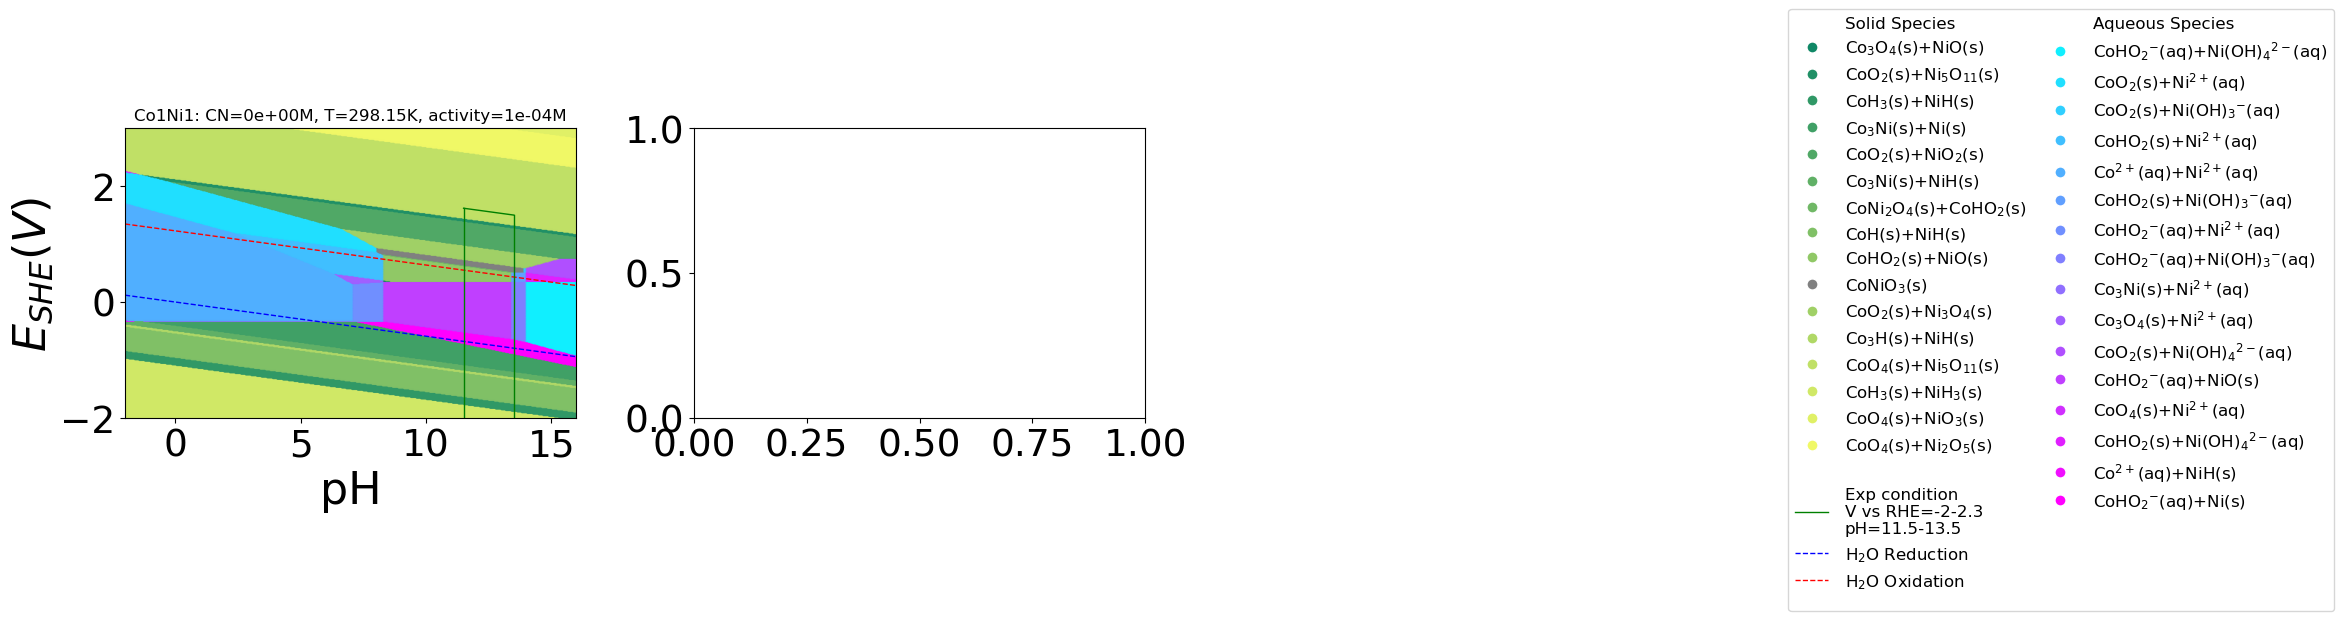

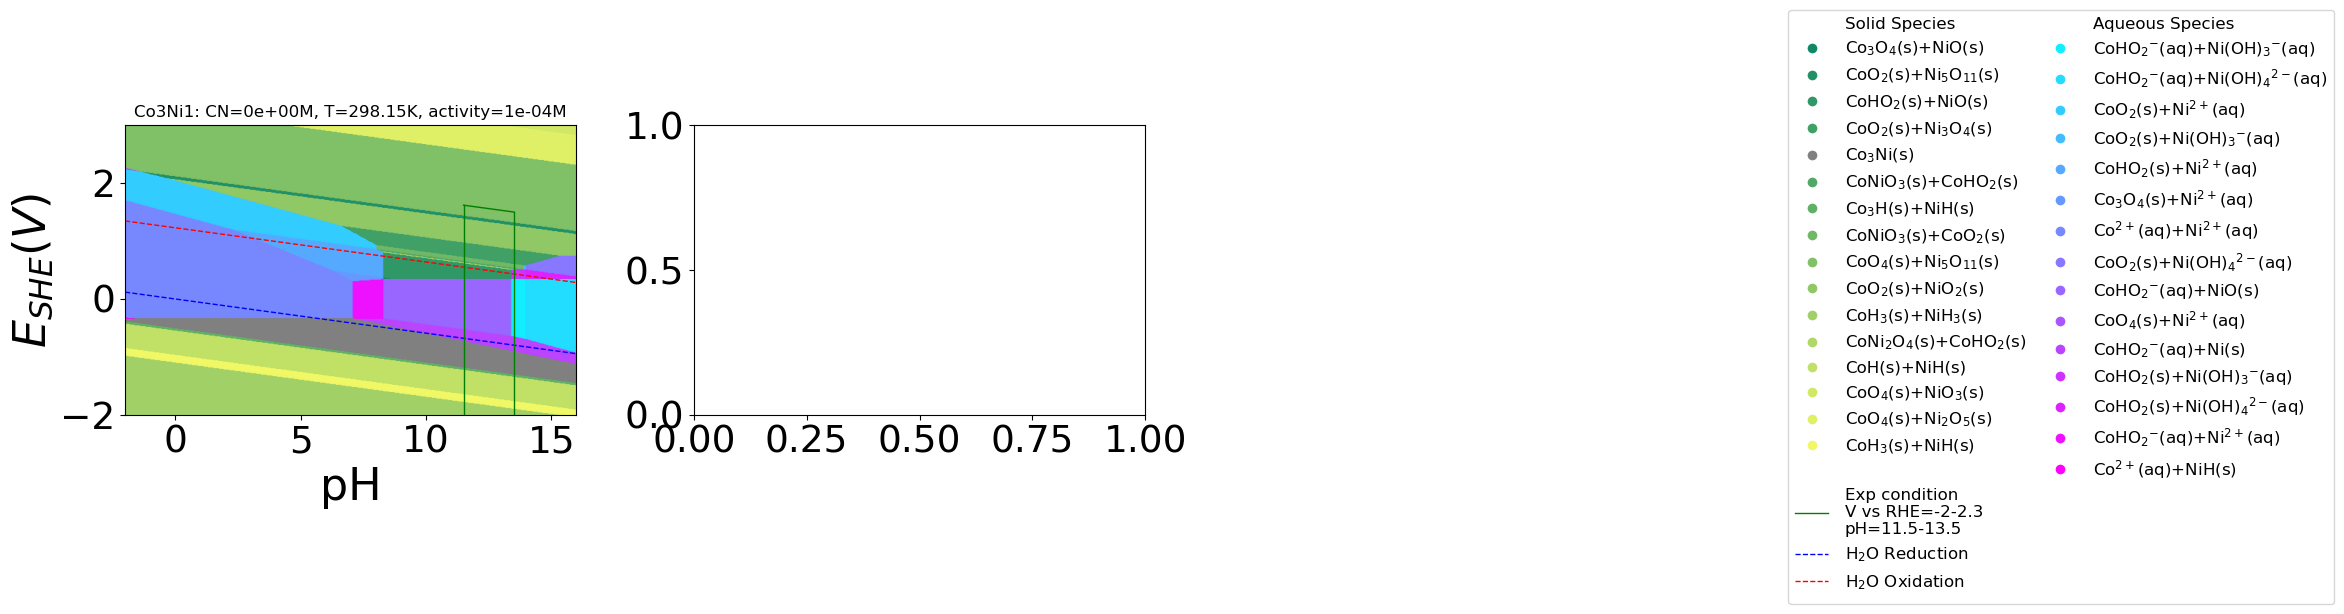

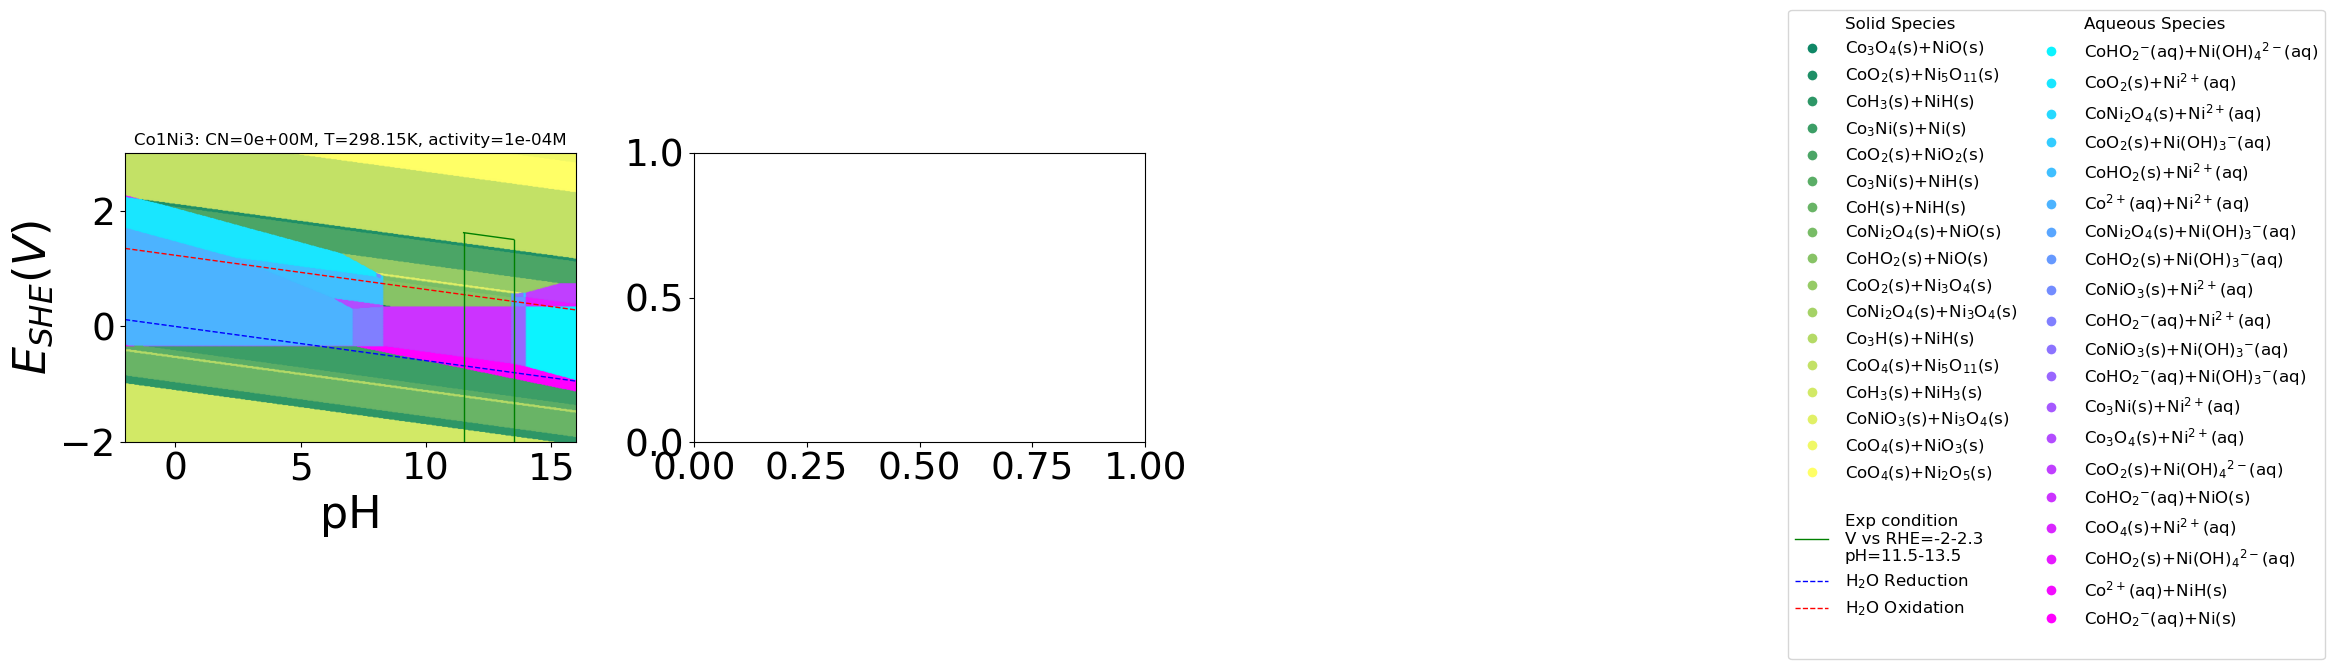

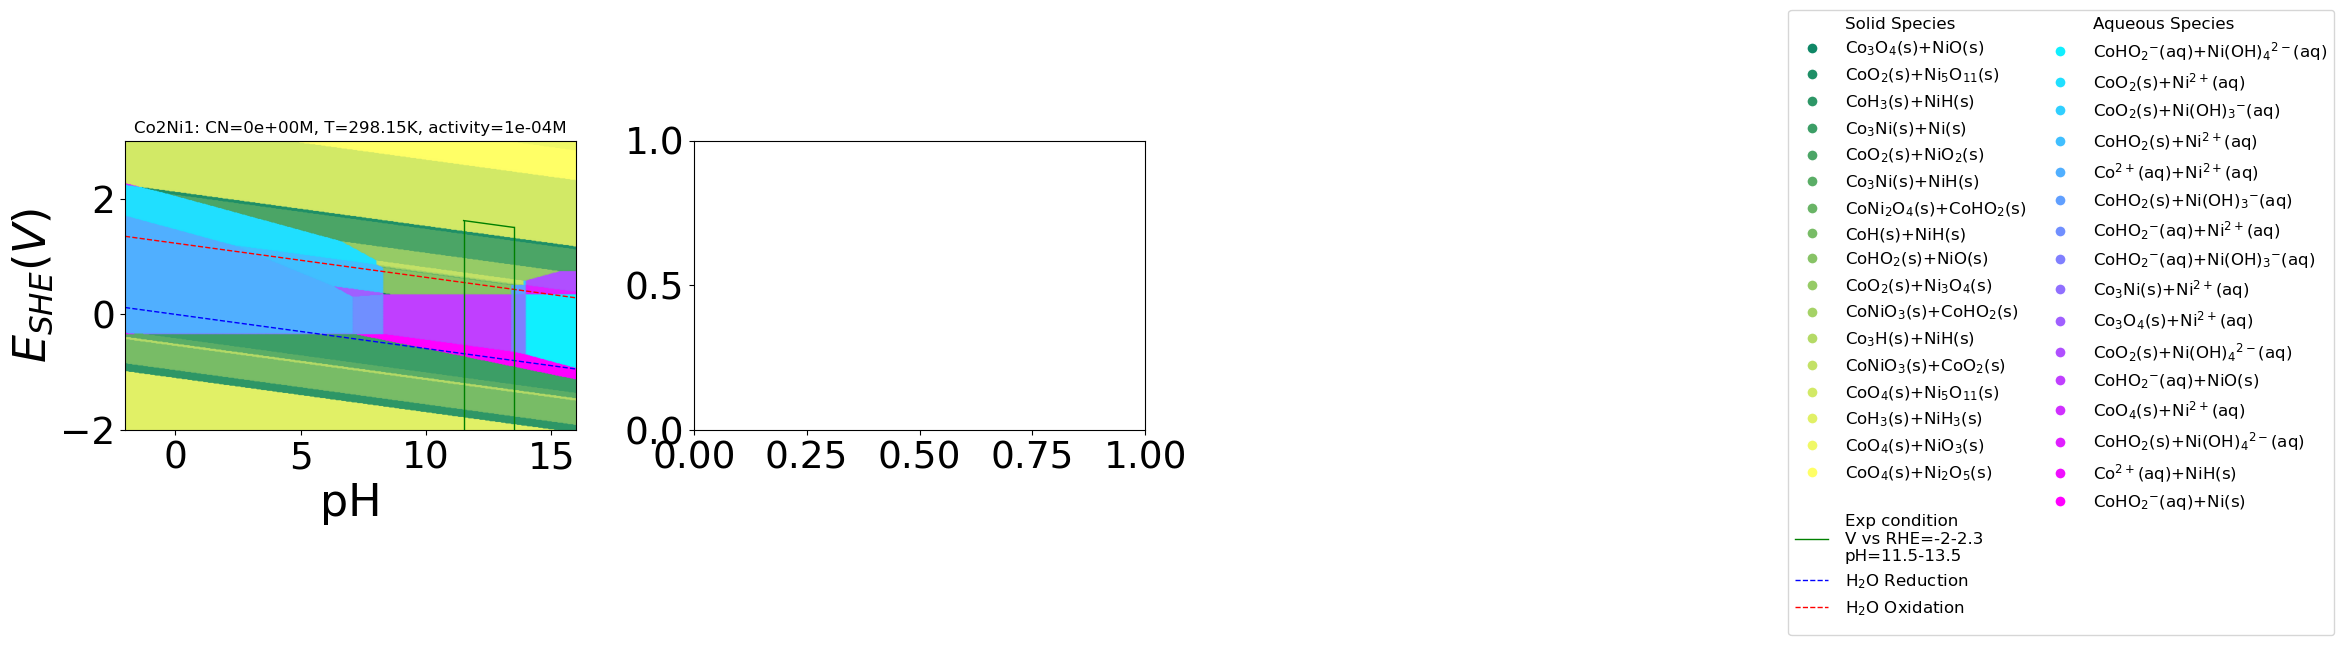

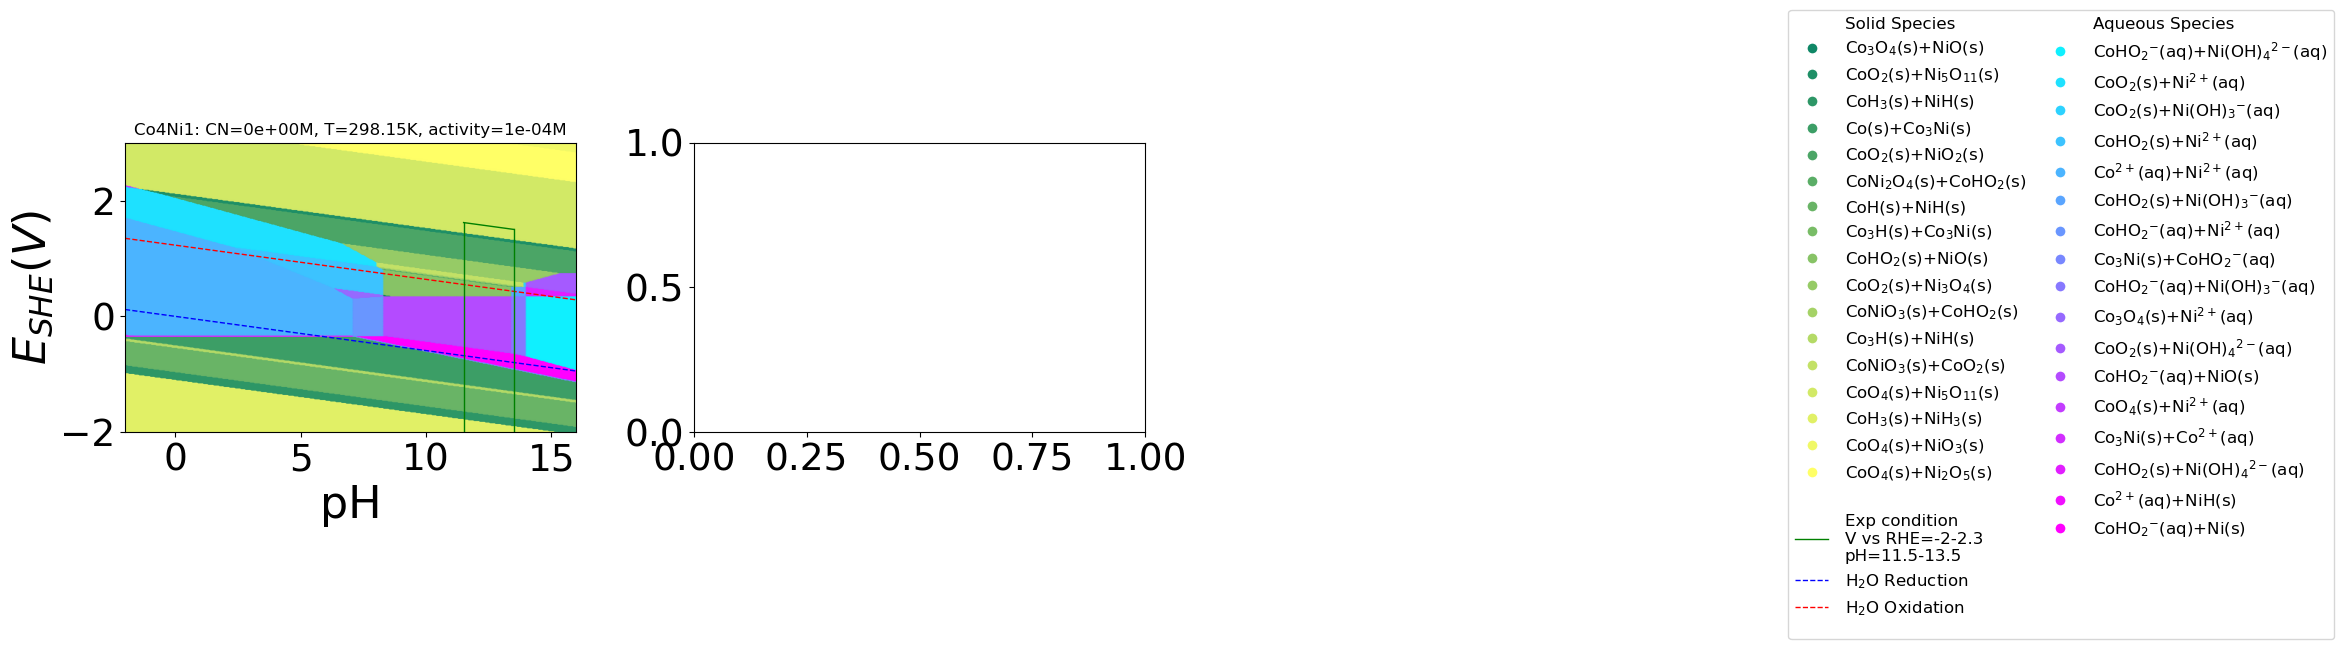

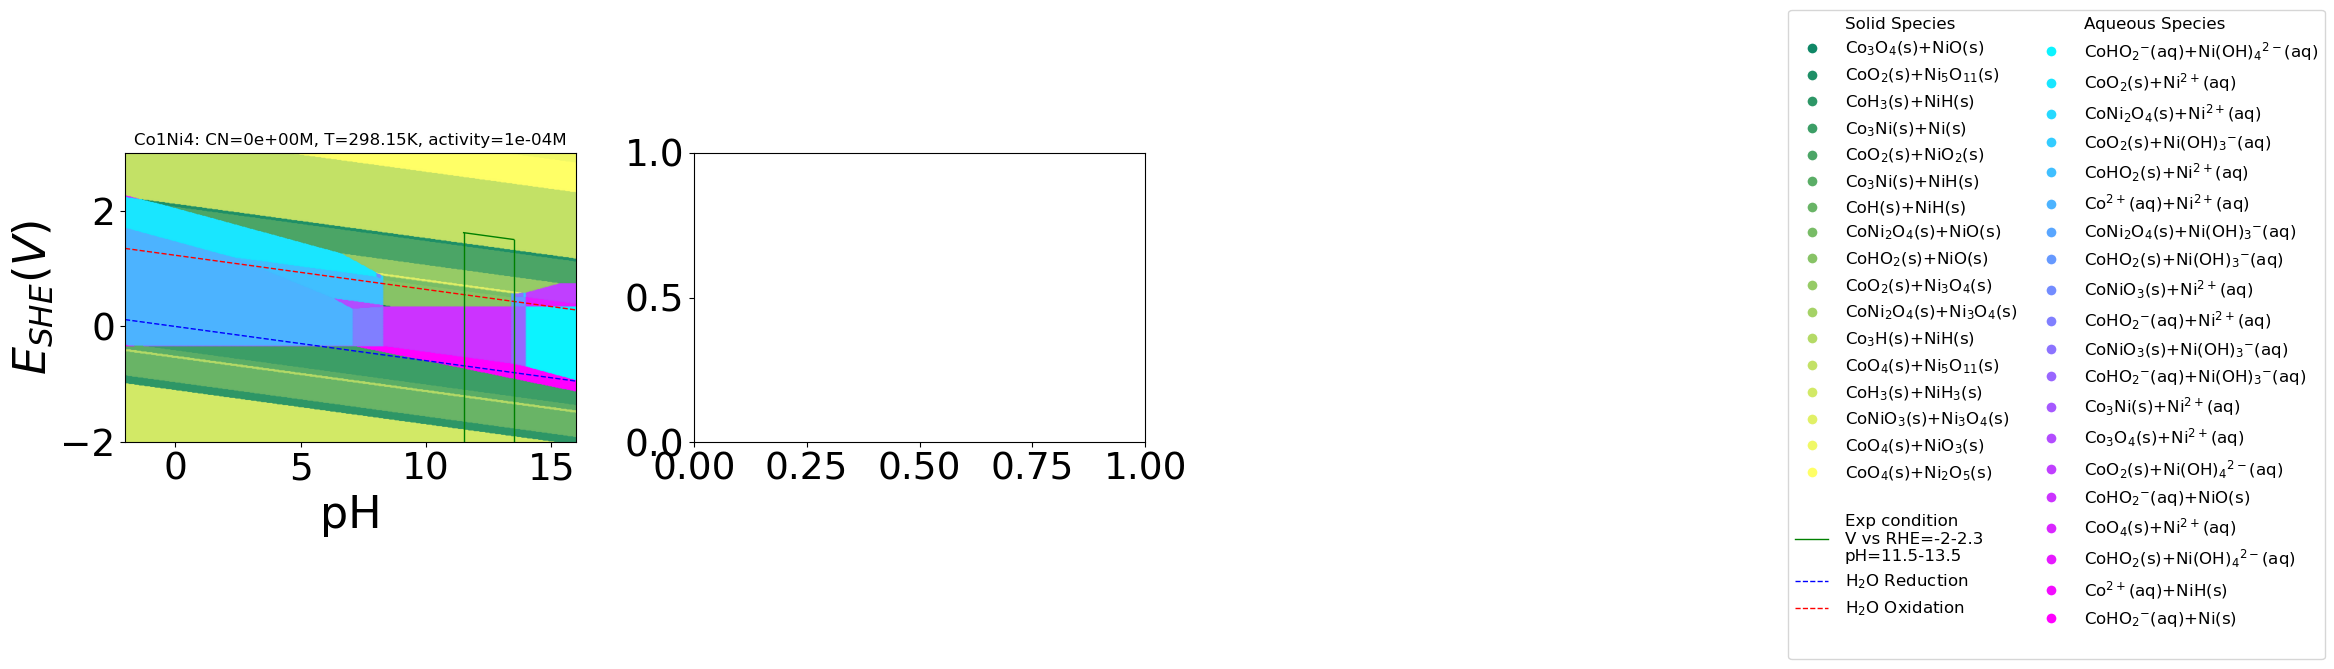

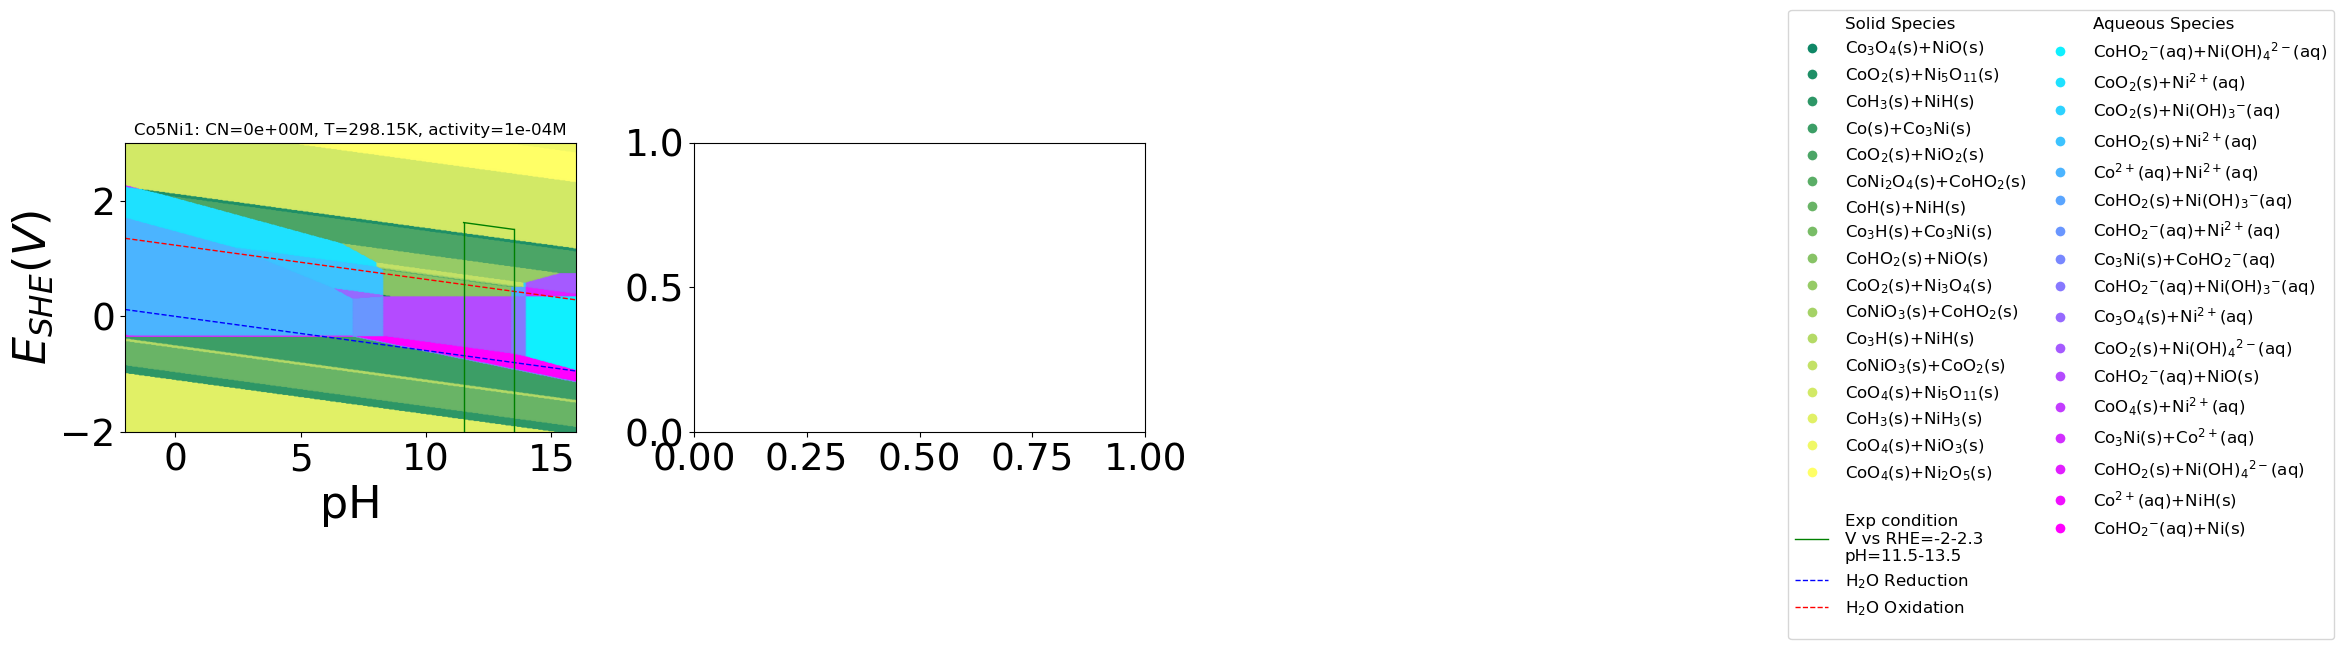

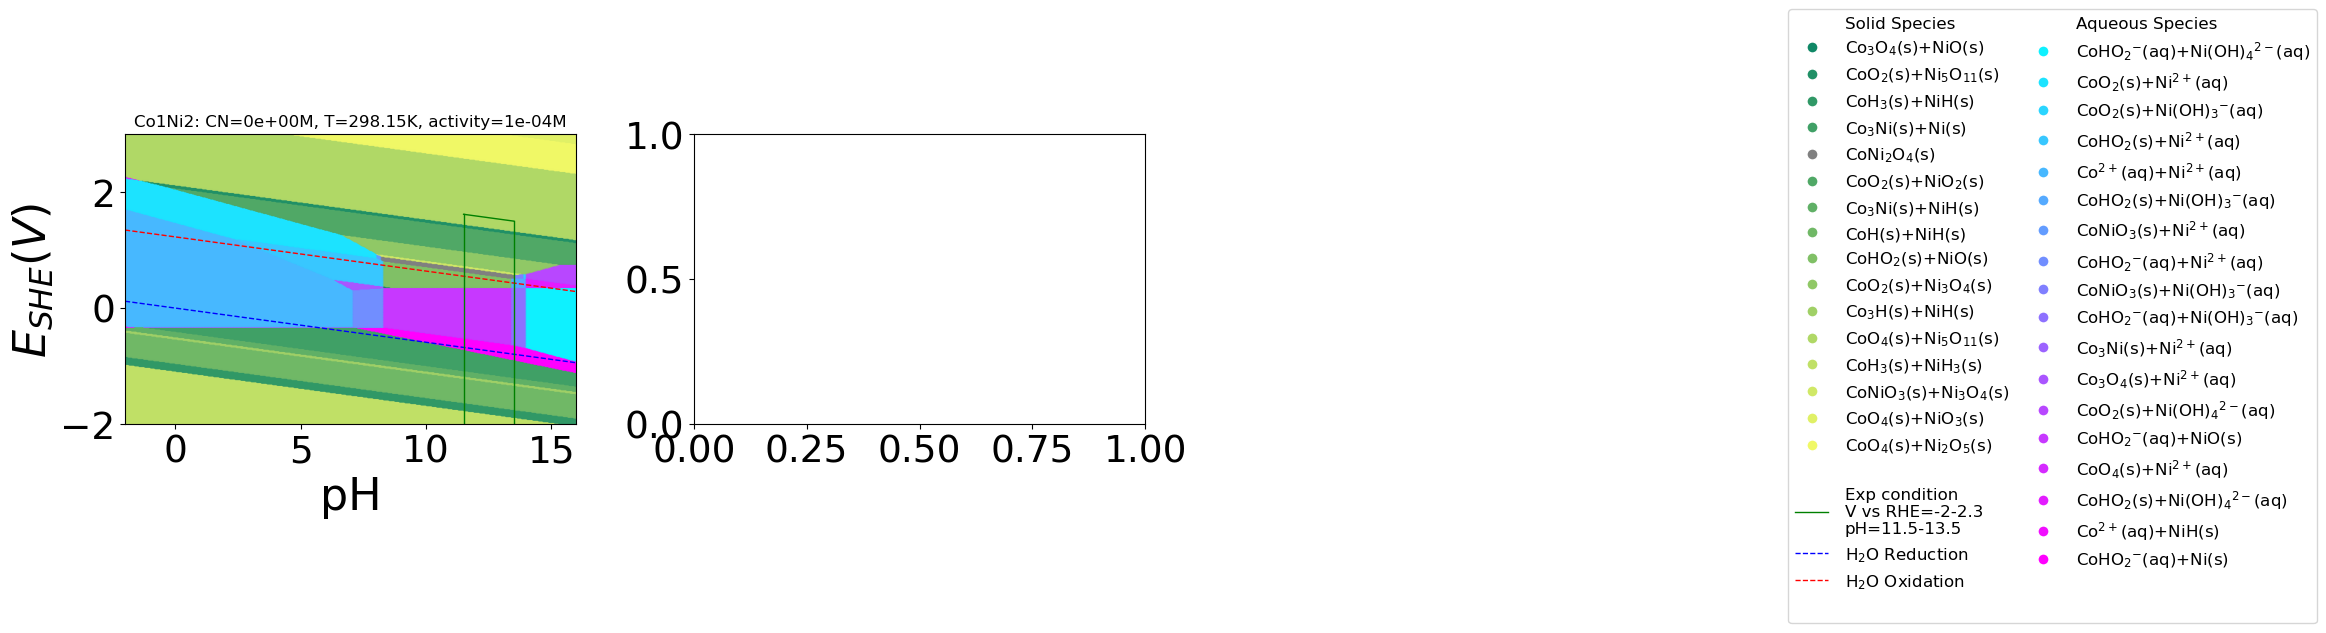

In [22]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pymatgen.core import Composition
import math

def parse_composition(formula):        
    element_only_form = formula.split('[')[0]
    symbol_list = string2symbols(element_only_form)
    return {symbol: symbol_list.count(symbol) for symbol in symbol_list if symbol not in ('O', 'H')}

def format_comp_dict(comp_dict):
    values = list(comp_dict.values())  
    gcd = math.gcd(*[int(round(v)) for v in values])  
    return ''.join(f"{metal}{int(comp_dict[metal]/gcd)}" for metal in comp_dict)

def generate_legends(ax, all_species_tuples_global, species_colors, plot_accessories):
    """Generate legends for solid, aqueous species, and accessory lines."""
    solid_handles = [Line2D([], [], linestyle="None", label="Solid Species")]
    aqueous_handles = [Line2D([], [], linestyle="None", label="Aqueous Species")]

    for species in all_species_tuples_global:
        label = plot_accessories.format_species_combo(species)
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=species_colors[species], markersize=8, label=label)
        (solid_handles if '(aq)' not in label else aqueous_handles).append(handle)
    
    accessory_handles = [
            Line2D([0], [0], color="g", linestyle="-", linewidth=1, label=f'Exp condition\nV vs RHE={V_exp_range[0]}-{V_exp_range[1]}\npH={pH_exp_range[0]}-{pH_exp_range[1]}'),
            Line2D([0], [0], color="b", linestyle="--", linewidth=1, label=r'H$_2$O Reduction'),
            Line2D([0], [0], color="r", linestyle="--", linewidth=1, label=r'H$_2$O Oxidation')
        ]
    solid_handles.extend([Line2D([], [], linestyle="None", label="")])
    solid_handles += accessory_handles # there are spaces after solid species
    
    max_len = max(len(solid_handles), len(aqueous_handles))
    solid_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(solid_handles)))
    aqueous_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(aqueous_handles)))

    
    combined_handles = solid_handles +aqueous_handles  #[item for pair in zip(solid_handles, aqueous_handles) for item in pair]
    combined_labels = [h.get_label() for h in combined_handles]

    combined_legend = ax.legend(
        solid_handles + aqueous_handles, 
        [h.get_label() for h in solid_handles + aqueous_handles],
        loc="center left", frameon=True, bbox_to_anchor=(1.01, 0.5), ncol=2, 
        columnspacing=1.0, handletextpad=1.0, fontsize=12
    )

#     ax.add_artist(accessory_legend)

def process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand):
    """Main function to process alloys, generate Pourbaix diagrams, and plot results."""
    for metal_2 in metal_list: 
        for T in T_list:
            species_data = SpeciesDataLoader(metal_1, metal_2, mu_ligand, T)
            prod_comp_dict = {
                format_comp_dict(parse_composition(alloy)): Composition({
                    metal: count / sum(parse_composition(alloy).values())
                    for metal, count in parse_composition(alloy).items()
                }) 
                for alloy in species_data.solid_eng if len(parse_composition(alloy)) >= 2
            }

            for reference_alloy, reference_composition in prod_comp_dict.items():
                species_grid_list, all_species_tuples_global = [], set()

                for CN, activity in itertools.product(CN_list, activity_list):
                    ligand_concentration = {'NH3': 0.0, 'Gly': 0.00, 'CN': CN}

#                     ligand_concentration = {'NH3': 0.02, 'Gly': 0.005, 'CN': CN}
                    grid_maker = GridMaker((-2, 16), (-2, 3), ligand_concentration, 400)
                    pourbaix_data = PourbaixData(species_data, activity, ligand_concentration, reference_composition)
                    analyzer = PourbaixAnalyzer(pourbaix_data, grid_maker, T)

                    species_grid, all_species_tuples_set = analyzer.analyze_and_plot()
                    species_grid_list.append((species_grid, CN, T, activity, reference_alloy))
                    all_species_tuples_global.update(all_species_tuples_set)
#                     break

                species_colors = PlotAccessories(species_data).get_color_for_label(all_species_tuples_global)
                
                num_plots = len(species_grid_list)
                cols = 3
                rows = (num_plots + cols - 1) // cols
                fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
                axes = axes.flatten()

                plot_idx = 0  
                for species_grid, CN, T, activity, reference_alloy in species_grid_list:
                    ax = axes[plot_idx]
                    visualizer = GridVisualizer(grid_maker, species_data)
                    visualizer.plot_species_distribution(species_grid, species_colors, ax=ax)
                    ax.set_title(f"{reference_alloy}: CN={CN:.0e}M, T={T}K, activity={activity:.0e}M", fontsize=12)
                    plot_idx += 1
                    
                for i in range(plot_idx+1, len(axes)):
                    fig.delaxes(axes[i])

                generate_legends(fig, all_species_tuples_global, species_colors, PlotAccessories(species_data))

                plt.tight_layout()
                plt.show()

metal_1 = 'Ti'
metal_1 = 'Ni'

metal_list = ['Mg', 'Mn','Fe','Ni', 'Co','Zn'] 
metal_list = ['Co']  

CN_list = [0, 1e-5, 1e-4]
CN_list = [0]
T_list = [298.15, 308.15, 323.15]
T_list = [298.15]

activity_list = [4e-4, 1e-4, 1e-5]
activity_list = [1e-4]

pH_exp_range, V_exp_range = (11.5, 13.5), (-2, 2.3)

mu_ligand = {'NH3': -0.276037, 'Gly': -3.263014109, 'CN': 1.786800089}

# --- Run Processing ---
process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand)


### Vary T and activity. Constant CN concentrations. Subplots

In [ ]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pymatgen.core import Composition
import math

def parse_composition(formula):        
    element_only_form = formula.split('[')[0]
    symbol_list = string2symbols(element_only_form)
    return {symbol: symbol_list.count(symbol) for symbol in symbol_list if symbol not in ('O', 'H')}

def format_comp_dict(comp_dict):
    values = list(comp_dict.values())  
    gcd = math.gcd(*[int(round(v)) for v in values])  
    return ''.join(f"{metal}{int(comp_dict[metal]/gcd)}" for metal in comp_dict)

def generate_legends(ax, all_species_tuples_global, species_colors, plot_accessories):
    """Generate legends for solid, aqueous species, and accessory lines."""
    solid_handles = [Line2D([], [], linestyle="None", label="Solid Species")]
    aqueous_handles = [Line2D([], [], linestyle="None", label="Aqueous Species")]

    for species in all_species_tuples_global:
        label = plot_accessories.format_species_combo(species)
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=species_colors[species], markersize=8, label=label)
        (solid_handles if '(aq)' not in label else aqueous_handles).append(handle)
    
    accessory_handles = [
            Line2D([0], [0], color="g", linestyle="-", linewidth=1, label=f'Exp condition\nV vs RHE={V_exp_range[0]}-{V_exp_range[1]}\npH={pH_exp_range[0]}-{pH_exp_range[1]}'),
            Line2D([0], [0], color="b", linestyle="--", linewidth=1, label=r'H$_2$O Reduction'),
            Line2D([0], [0], color="r", linestyle="--", linewidth=1, label=r'H$_2$O Oxidation')
        ]
    solid_handles.extend([Line2D([], [], linestyle="None", label="")])
    solid_handles += accessory_handles # there are spaces after solid species
    
    max_len = max(len(solid_handles), len(aqueous_handles))
    solid_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(solid_handles)))
    aqueous_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(aqueous_handles)))

    
    combined_handles = solid_handles +aqueous_handles  #[item for pair in zip(solid_handles, aqueous_handles) for item in pair]
    combined_labels = [h.get_label() for h in combined_handles]

    combined_legend = ax.legend(
        solid_handles + aqueous_handles, 
        [h.get_label() for h in solid_handles + aqueous_handles],
        loc="center left", frameon=True, bbox_to_anchor=(1.01, 0.5), ncol=2, 
        columnspacing=1.0, handletextpad=1.0, fontsize=12
    )

#     ax.add_artist(accessory_legend)

def process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand):
    """Main function to process alloys, generate Pourbaix diagrams, and plot results."""
    for metal_2 in metal_list: 
        print(metal_2)
        for CN in CN_list:
            species_data = SpeciesDataLoader(metal_1, metal_2, mu_ligand, T=298.15)
            prod_comp_dict = {
                format_comp_dict(parse_composition(alloy)): Composition({
                    metal: count / sum(parse_composition(alloy).values())
                    for metal, count in parse_composition(alloy).items()
                }) 
                for alloy in species_data.solid_eng if len(parse_composition(alloy)) >= 2
            }

            for reference_alloy, reference_composition in prod_comp_dict.items():
                species_grid_list, all_species_tuples_global = [], set()

                for T, activity in itertools.product(T_list, activity_list):
                    ligand_concentration = {'NH3': 0.02, 'Gly': 0.005, 'CN': CN}
                    grid_maker = GridMaker((-2, 16), (-2, 3), ligand_concentration, 400)
                    species_data = SpeciesDataLoader(metal_1, metal_2, mu_ligand, T)
                    pourbaix_data = PourbaixData(species_data, activity, ligand_concentration, reference_composition)
                    analyzer = PourbaixAnalyzer(pourbaix_data, grid_maker, T)

                    species_grid, all_species_tuples_set = analyzer.analyze_and_plot()
                    species_grid_list.append((species_grid, CN, T, activity, reference_alloy))
                    all_species_tuples_global.update(all_species_tuples_set)

                species_colors = PlotAccessories(species_data).get_color_for_label(all_species_tuples_global)
                
                num_plots = len(species_grid_list)
                cols = 3
                rows = (num_plots + cols - 1) // cols
                fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
                axes = axes.flatten()

                plot_idx = 0  
                for species_grid, CN, T, activity, reference_alloy in species_grid_list:
                    ax = axes[plot_idx]
                    visualizer = GridVisualizer(grid_maker, species_data)
                    visualizer.plot_species_distribution(species_grid, species_colors, ax=ax)
                    ax.set_title(f"{reference_alloy}: CN={CN:.0e}M, T={T}K, activity={activity:.0e}M", fontsize=12)
                    plot_idx += 1
                    
                for i in range(plot_idx+1, len(axes)):
                    fig.delaxes(axes[i])

                generate_legends(fig, all_species_tuples_global, species_colors, PlotAccessories(species_data))

                plt.tight_layout()
                plt.show()

metal_1 = 'Co'
metal_list = ['Ni']  
# metal_list = ['Cu']  

CN_list = [0]
T_list = [298.15, 308.15, 323.15]
# T_list = [298.15]

activity_list = [4e-4, 1e-4, 1e-5]
pH_exp_range, V_exp_range = (11.5, 13.5), (-2, 2.3)

mu_ligand = {'NH3': -0.276037, 'Gly': -3.263014109, 'CN': 1.786800089}

# --- Run Processing ---
process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand)


### Vary T, reference alloys and CN concentrations. Single figure.

In [ ]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pymatgen.core import Composition
import math

def parse_composition(formula):        
    element_only_form = formula.split('[')[0]
    symbol_list = string2symbols(element_only_form)
    return {symbol: symbol_list.count(symbol) for symbol in symbol_list if symbol not in ('O', 'H')}

def format_comp_dict(comp_dict):
    values = list(comp_dict.values())  
    gcd = math.gcd(*[int(round(v)) for v in values])  
    return ''.join(f"{metal}{int(comp_dict[metal]/gcd)}" for metal in comp_dict)

def generate_legends(ax, all_species_tuples_global, species_colors, plot_accessories):
    """Generate legends for solid, aqueous species, and accessory lines."""
    solid_handles = [Line2D([], [], linestyle="None", label="Solid Species")]
    aqueous_handles = [Line2D([], [], linestyle="None", label="Aqueous Species")]

    for species in all_species_tuples_global:
        label = plot_accessories.format_species_combo(species)
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=species_colors[species], markersize=8, label=label)
        (solid_handles if '(aq)' not in label else aqueous_handles).append(handle)

    max_len = max(len(solid_handles), len(aqueous_handles))
    solid_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(solid_handles)))
    aqueous_handles.extend([Line2D([], [], linestyle="None", label="")] * (max_len - len(aqueous_handles)))

    accessory_handles = [
            Line2D([0], [0], color="g", linestyle="-", linewidth=1, label=f'Exp condition\nV vs RHE={V_exp_range[0]}-{V_exp_range[1]}\npH={pH_exp_range[0]}-{pH_exp_range[1]}'),
            Line2D([0], [0], color="b", linestyle="--", linewidth=1, label=r'H$_2$O Reduction'),
            Line2D([0], [0], color="r", linestyle="--", linewidth=1, label=r'H$_2$O Oxidation')
        ]
    accessory_legend = ax.legend(
        handles=accessory_handles,
        loc="upper right", frameon=True
    )
    
    combined_handles = solid_handles +aqueous_handles  #[item for pair in zip(solid_handles, aqueous_handles) for item in pair]
    combined_labels = [h.get_label() for h in combined_handles]

    combined_legend = ax.legend(
        solid_handles + aqueous_handles, 
        [h.get_label() for h in solid_handles + aqueous_handles],
        loc="center left", frameon=True, bbox_to_anchor=(1.01, 0.5), ncol=2, 
        columnspacing=1.0, handletextpad=1.0, fontsize=12
    )

    ax.add_artist(accessory_legend)

def process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand):
    """Main function to process alloys, generate Pourbaix diagrams, and plot results."""
    for metal_2 in metal_list: 
        for T in T_list:
            species_data = SpeciesDataLoader(metal_1, metal_2, mu_ligand, T)
            prod_comp_dict = {
                format_comp_dict(parse_composition(alloy)): Composition({
                    metal: count / sum(parse_composition(alloy).values())
                    for metal, count in parse_composition(alloy).items()
                }) 
                for alloy in species_data.solid_eng if len(parse_composition(alloy)) >= 2
            }

            for reference_alloy, reference_composition in prod_comp_dict.items():
                species_grid_list, all_species_tuples_global = [], set()

                for CN, activity in itertools.product(CN_list, activity_list):
                    ligand_concentration = {'NH3': 0.02, 'Gly': 0.005, 'CN': CN}
                    grid_maker = GridMaker((-2, 16), (-2, 3), ligand_concentration, 400)
                    pourbaix_data = PourbaixData(species_data, activity, ligand_concentration, reference_composition)
                    analyzer = PourbaixAnalyzer(pourbaix_data, grid_maker, T)

                    species_grid, all_species_tuples_set = analyzer.analyze_and_plot()
                    species_grid_list.append((species_grid, CN, T, activity, reference_alloy))
                    all_species_tuples_global.update(all_species_tuples_set)

                fig, ax = plt.subplots(figsize=(14, 8))
                species_colors = PlotAccessories(species_data).get_color_for_label(all_species_tuples_global)

                for species_grid, CN, T, activity, reference_alloy in species_grid_list:
                    fig, ax = GridVisualizer(grid_maker, species_data).plot_species_distribution(species_grid, species_colors, ax=ax)
                    ax.set_title(f"{reference_alloy}: CN={CN:.0e}M, T={T}K, activity={activity:.0e}M", fontsize=12)

                generate_legends(ax, all_species_tuples_global, species_colors, PlotAccessories(species_data))

                plt.tight_layout()
                plt.show()

metal_1 = 'Ti'
metal_list = ['Ni']  
CN_list = [0]
T_list = [298.15, 308.15, 323.15]
activity_list = [1e-4]
pH_exp_range, V_exp_range = (11.5, 13.5), (-2, 2.3)

mu_ligand = {'NH3': -0.276037, 'Gly': -3.263014109, 'CN': 1.786800089}

# --- Run Processing ---
process_alloys(metal_1, metal_list, CN_list, T_list, activity_list, mu_ligand)


In [ ]:
# metal_1='Ti' 
# metal_2='Ni'
# # metal_list = ['Au', 'Cu', 'Ni', 'Co',  'Mg', 'Mn','Zn', 'Ag', 'Cd','Sr','Pt','Pd'] #'Fe',
# # for metal_2 in metal_list:
# # metal_2='Fe' # save stable alloy species from pymatgen alloy pbx then draw

# mu_ligand={'NH3':-0.276037,
#           'Gly': -3.263014109,
#            'CN':1.786800089
#           }

# ligand_concentration={'NH3':0.0,
#           'Gly': 0.0,
#           'CN':0
#                      }
# ligand_concentration={'NH3':0.02,# 0.02M = 370 ppm, # M = molar
#           'Gly': 0.005,#0.005M = 370 ppm,
#           'CN':0 #0#,
#                      }
# # ligand_concentration={'NH3':0.02,# 0.02M = 370 ppm, # M = molar
# #           'Gly': 0.005,#0.005M = 370 ppm,
# #           'CN':1e-4
# #                      }

# activity = 1e-4
# pH_range = (-2, 16)  # pH values
# V_range = (-2, 3)  # V values
# grid_size = 400

# grid_maker = GridMaker(pH_range, V_range, ligand_concentration, grid_size)
# species_data = SpeciesDataLoader(metal_1, metal_2, mu_ligand)

# individual_stable_species = species_data.stable_species
# solid_eng = species_data.solid_eng
# ion_eng =  species_data.ion_eng
# metal_complex = species_data.metal_complex
# complex_label_dict = species_data.species_label_dict
# metal_reference = species_data.metal_reference

# pourbaix_data = PourbaixData(species_data, activity, ligand_concentration,reference_composition)

# # Create analyzer and run analysis
# analyzer = PourbaixAnalyzer(pourbaix_data, grid_maker,complex_label_dict)
# analyzer.analyze_and_plot()



In [ ]:
# metal_1='Ti' 
# # # metal_2='Ni'
# metal_list = ['Au', 'Cu', 'Ni', 'Co',   'Mn','Zn', 'Ag', 'Cd','Sr','Pt','Pd','Mg','Fe'] #'Fe','Mg',
# # metal_list = ['Mg'] #'Fe','Mg',

# for metal_2 in metal_list:
#     mu_ligand={'NH3':-0.276037,
#               'Gly': -3.263014109,
#                'CN':1.786800089
#               }
# #     ligand_concentration={'NH3':0.02,# 0.02M = 370 ppm, # M = molar
# #               'Gly': 0.005,#0.005M = 370 ppm,
# #               'CN':0 #0#,
# #                          }
# #     ligand_concentration={'NH3':0.02,# 0.02M = 370 ppm, # M = molar
# #               'Gly': 0.005,#0.005M = 370 ppm,
# #               'CN':1e-4 #0#,
# #                          }

#     activity = 1e-4#1e-6
#     pH_range = (-2, 16)  # pH values
#     V_range = (-2, 3)  # V values
#     grid_size = 900

#     grid_maker = GridMaker(pH_range, V_range, ligand_concentration, grid_size)
#     species_data = SpeciesDataLoader(metal_1, metal_2, mu_ligand)

#     individual_stable_species = species_data.stable_species
#     solid_eng = species_data.solid_eng
#     ion_eng =  species_data.ion_eng
#     metal_complex = species_data.metal_complex
#     complex_label_dict = species_data.species_label_dict
#     metal_reference = species_data.metal_reference

#     pourbaix_data = PourbaixData(solid_eng, ion_eng, metal_complex, mu_ligand, individual_stable_species, metal_reference, activity=activity)

#     # Create analyzer and run analysis
#     analyzer = PourbaixAnalyzer(pourbaix_data, grid_maker,complex_label_dict)
#     analyzer.analyze_and_plot()



In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from matplotlib.colors import to_rgba
# import colorsys


# class GridVisualizer:
#     def __init__(self, grid_maker, complex_label_dict, species_data):
#         """Takes a GridMaker instance and uses it for visualization."""
#         self.grid_maker = grid_maker
#         self.complex_label_dict = complex_label_dict
#         self.metal_list = [key for key in  species_data.metal_reference.keys()]
#         self.species_data = species_data

#     def format_formula(self, formula):
#         """Converts a chemical formula to a LaTeX-friendly format."""
#         formatted_formula = re.sub(r"([A-Za-z\(\)])([\d\+\-\.]+)", r"\1$_{\2}$", formula)
#         formatted_formula = re.sub(r"\[([\d\+\-]+)\]", r"$^{\1}$", formatted_formula)
#         return formatted_formula

#     def format_species_combo(self, combo_tuple):
#         """Formats species with their phase labels for plotting."""
#         species_list = sorted(combo_tuple, key=lambda species: species.name)

#         for i in range(len(species_list)):
#             species = species_list[i]
#             phase = species.phase
#             if phase == 'complex':
#                 true_charge_formula = complex_label_dict[species.formula]
#                 formatted_species = self.format_formula(true_charge_formula)
#             else:
#                 formatted_species = self.format_formula(species.formula)
#             species_list[i] = formatted_species + ('(s)' if phase == 'solid' else '(aq)')
#         return '+'.join(species_list)
    
#     def count_total_phases(self, all_species_tuples):
#         total_solid = 0
        
#         for combo_tuple in all_species_tuples:
#             if all(species.phase == 'solid' for species in combo_tuple):
#                 total_solid += 1
#         total_aq = len(all_species_tuples) - total_solid
#         return total_solid, total_aq
    
#     def get_color_for_label(self, all_species_tuples): 
#         species_colors = {}
#         total_solid, total_aq = self.count_total_phases(all_species_tuples)
        
#         warmer_color_map = plt.cm.get_cmap('summer')  # Warmer colors
#         cooler_color_map = plt.cm.get_cmap('cool')  # Cooler colors
#         grey_color = to_rgba('grey')
#         solid_index = 0
#         aq_index = 0
        
#         for combo_tuple in all_species_tuples:  
    
#             if any(species.alloy == True for species in combo_tuple) and all(species.phase == 'solid' for species in combo_tuple):
#                 species_colors[combo_tuple] = grey_color #warmer_color_map(normalized_index)
                
#             elif all(species.phase == 'solid' for species in combo_tuple):
#                 solid_index += 1
#                 normalized_index = solid_index/total_solid
#                 species_colors[combo_tuple] = warmer_color_map(normalized_index)
#             else:
#                 aq_index += 1
#                 normalized_index = aq_index/total_aq
#                 species_colors[combo_tuple] = cooler_color_map(normalized_index)
        
#         return species_colors
    
#     def get_hue_from_color(self, color):
#         """Convert an RGB(A) color to its hue value in HSV color space."""
#         r, g, b, *_ = color  # Extract RGB values, ignore alpha if present
#         h, _, _ = colorsys.rgb_to_hsv(r, g, b)  # Convert to HSV and extract hue
#         return h 
    
#     def add_H2_O2_lines(self, plt, legend_elements):
#         PREFAC = 0.0591
#         xlim = self.grid_maker.pH_range
#         ylim = self.grid_maker.V_range
#         h_line = np.transpose([[xlim[0], -xlim[0] * PREFAC], [xlim[1], -xlim[1] * PREFAC]])
#         o_line = np.transpose([[xlim[0], -xlim[0] * PREFAC + 1.23], [xlim[1], -xlim[1] * PREFAC + 1.23]])
        
#         lw = 1
#         # Plot the hydrogen and oxygen lines on the axis 
#         h_line_plot, = plt.plot(h_line[0], h_line[1], "b--", linewidth=lw, label= r'H$_2$O Reduction')
#         o_line_plot, = plt.plot(o_line[0], o_line[1], "r--", linewidth=lw, label= r'H$_2$O Oxidation')
#         legend_elements.append(h_line_plot)
#         legend_elements.append(o_line_plot)
        
#     def add_plot_accessories(self, plt, legend_elements, pH_exp_range=(11.5,13.5), V_exp_range=(-2, 2.3), ):
#         PREFAC = 0.0591
#         box_left = pH_exp_range[0]
#         box_right = pH_exp_range[1]
        
        
#         V_left_bottom = V_exp_range[0] - PREFAC * box_left
#         V_right_bottom = V_exp_range[0] - PREFAC * box_right
#         V_left_top = V_exp_range[1] - PREFAC * box_left
#         V_right_top = V_exp_range[1] - PREFAC * box_right
        
#         lw = 1
#         style = 'g-'
#         bottom, = plt.plot([box_left, box_right], [V_left_bottom, V_right_bottom], style, lw=lw, label = f'Exp condition\nV vs RHE={V_exp_range[0]}-{V_exp_range[1]}\npH={pH_exp_range[0]}-{pH_exp_range[1]}')  # Bottom side (V as a function of pH)
#         top, = plt.plot([box_left, box_right], [V_left_top, V_right_top], style, lw=lw, label = f'{V_exp_range[1]}V vs RHE')        # Top side (V as a function of pH)
#         left, = plt.plot([box_left, box_left], [V_left_bottom, V_left_top], style, lw=lw, label = f'pH={pH_exp_range[0]}')       # Left side (fixed pH = box_left)
#         right, = plt.plot([box_right, box_right], [V_right_bottom, V_right_top], style, lw=lw,label = f'pH={pH_exp_range[1]}')     # Right side (fixed pH = box_right)
#         legend_elements.append(bottom)

        
#     def format_file_name(self):
#         ligand_concentration = self.species_data.ligand_concentration
#         NH3 = ligand_concentration['NH3']
#         Gly = ligand_concentration['Gly']
#         CN = ligand_concentration['CN']
#         activity = self.species_data.activity
#         metal_list = "_".join(self.metal_list)
        
#         reference_composition = self.species_data.reference_composition
#         file_name = f'figures/pourbaix_diagrams/{metal_list}_alloy_{reference_composition}_NH3={NH3}M_Gly={Gly}M_CN={CN}M_activity={activity:.0e}M.png'
#         return file_name
    
#     def plot_species_distribution(self, species_grid, all_species_tuples, ax=None, fontsize=18, save_fig = True):
#         """Plots the Pourbaix diagram using species distribution data."""
# #         n_unique_species = len(all_species_tuples)
#         species_colors = self.get_color_for_label(all_species_tuples)
        
#         color_values = np.array([species_colors[species] for species in species_grid.flatten()])
#         if ax is None:
#             fig, ax = plt.subplots(figsize=(6, 6))  # Create new figure if no axis is provided
#         else:
#             fig = ax.figure
#         ax.set_xlim(self.grid_maker.pH_range)
#         ax.set_ylim(self.grid_maker.V_range)
#         ax.scatter(self.grid_maker.pH_grid.flatten(), self.grid_maker.V_grid.flatten(), 
#                    c=color_values, s=1, alpha=0.75)
        
#         ax.set_xlabel('pH', fontsize=fontsize)
#         ax.set_ylabel(r'$E_{SHE}(V)$', fontsize=fontsize)
            
# # #         plt.figure(figsize=(10, 10))
# #         plt.xlim([self.grid_maker.pH_range[0], self.grid_maker.pH_range[1]])
# #         plt.ylim([self.grid_maker.V_range[0], self.grid_maker.V_range[1]])
# #         plt.scatter(self.grid_maker.pH_grid.flatten(), self.grid_maker.V_grid.flatten(), 
# #                     c=color_values, s=1, alpha=0.75)

#         legend_elements = [Line2D([0], [0], marker='o', color='w',
#                                   markerfacecolor=species_colors[species], markersize=8, 
#                                   label=self.format_species_combo(species))
#                            for species in all_species_tuples]
#         legend_elements = sorted(
#             legend_elements, 
#             key=lambda element: -self.get_hue_from_color(element.get_markerfacecolor())  # Negative to put summer first
#         )
#         return fig, ax, legend_elements 

        
# #         self.add_H2_O2_lines(plt, legend_elements)
# #         self.add_plot_accessories(plt, legend_elements)
# #         plt.legend(handles=legend_elements, loc='center left',fontsize=11.5, bbox_to_anchor=(1.05, 0.5))
# #         plt.xlabel('pH', fontsize=fontsize)
# #         plt.ylabel(r'$E_{SHE}(V)$', fontsize=fontsize)
# #         if save_fig:
# #             file_name = self.format_file_name()
# # #             file_name = f'figures/pourbaix_diagrams/{"_".join(self.metal_list)}_alloy.png'
# #             print(file_name)
# #             plt.savefig(file_name, bbox_inches='tight')
# #         plt.show()
